In [1]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df_origin = pd.read_csv('2019-Oct_smartphone_preprocessed_final.csv')
df = df_origin.copy()

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_price_error,hour,day_of_week,day_name,time_segment,is_outlier,is_purchase,is_cart
0,2019-10-01 09:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,False,9,1,Tuesday,오전 (6-12시),False,0,0
1,2019-10-01 09:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,False,9,1,Tuesday,오전 (6-12시),False,0,0
2,2019-10-01 09:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.64,530282093,50a293fb-5940-41b2-baf3-17af0e812101,False,9,1,Tuesday,오전 (6-12시),False,0,0
3,2019-10-01 09:00:19,view,1005135,2053013555631882655,electronics.smartphone,apple,1747.79,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,False,9,1,Tuesday,오전 (6-12시),False,0,0
4,2019-10-01 09:00:20,view,1003306,2053013555631882655,electronics.smartphone,apple,588.77,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,False,9,1,Tuesday,오전 (6-12시),False,0,0


In [5]:
df['category_main'] = df['category_code'].str.split('.').str[0]
df['category_sub'] = df['category_code'].str.split('.').str[1]

print(df['category_main'].unique)
print(df['category_sub'].unique)

<bound method Series.unique of 0           electronics
1           electronics
2           electronics
3           electronics
4           electronics
               ...     
11471291    electronics
11471292    electronics
11471293    electronics
11471294    electronics
11471295    electronics
Name: category_main, Length: 11471296, dtype: object>
<bound method Series.unique of 0           smartphone
1           smartphone
2           smartphone
3           smartphone
4           smartphone
               ...    
11471291    smartphone
11471292    smartphone
11471293    smartphone
11471294    smartphone
11471295    smartphone
Name: category_sub, Length: 11471296, dtype: object>


In [6]:
df['category_code'].value_counts()

category_code
electronics.smartphone    11471296
Name: count, dtype: int64

In [7]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts()

brand
samsung       3761749
apple         3261060
xiaomi        2196966
huawei         999480
oppo           481612
meizu          155472
vivo           113037
honor           76879
nokia           70616
sony            67451
oneplus         65850
lg              24120
tp-link         22660
unknown         21880
bq              20786
doogee          18176
inoi            16565
google          15435
prestigio       14288
haier           11048
zte             10761
asus             6617
tecno            5932
jinga            4471
gionee           4037
umi              3724
blackberry       3685
irbis            3483
htc              3294
fly              2922
nubia            2099
texet            1291
leeco            1046
vertex            915
micromax          673
philips           625
oukitel           235
leagoo            205
hiper              67
ark                60
motorola           23
bravis              1
Name: count, dtype: int64

In [8]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts(normalize=True) * 100

brand
samsung       32.792711
apple         28.428000
xiaomi        19.151855
huawei         8.712878
oppo           4.198410
meizu          1.355313
vivo           0.985390
honor          0.670186
nokia          0.615589
sony           0.587998
oneplus        0.574042
lg             0.210264
tp-link        0.197537
unknown        0.190737
bq             0.181200
doogee         0.158448
inoi           0.144404
google         0.134553
prestigio      0.124554
haier          0.096310
zte            0.093808
asus           0.057683
tecno          0.051712
jinga          0.038976
gionee         0.035192
umi            0.032464
blackberry     0.032124
irbis          0.030363
htc            0.028715
fly            0.025472
nubia          0.018298
texet          0.011254
leeco          0.009118
vertex         0.007976
micromax       0.005867
philips        0.005448
oukitel        0.002049
leagoo         0.001787
hiper          0.000584
ark            0.000523
motorola       0.000201
bravis    

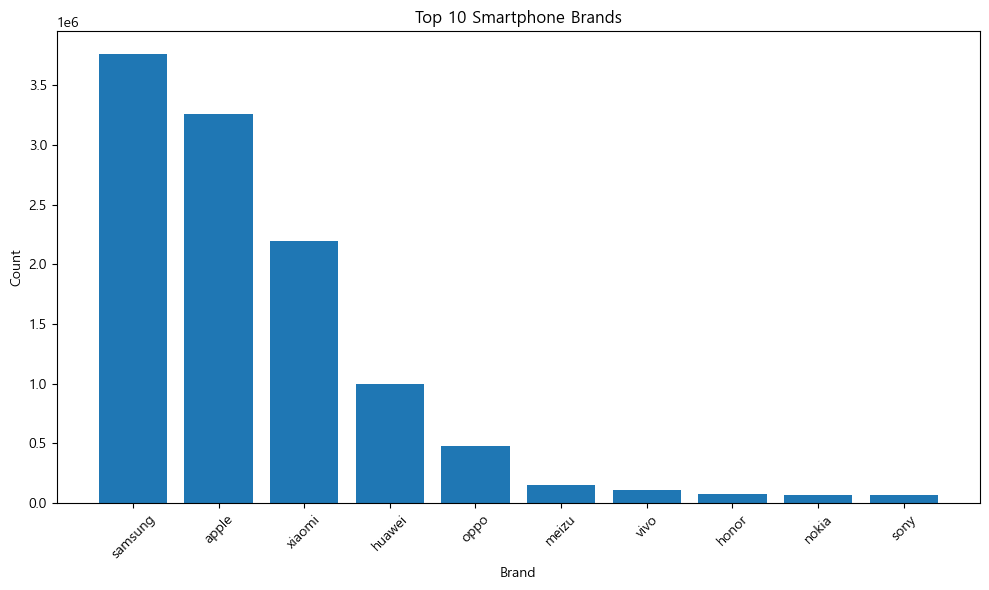

In [9]:
top_brands = df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_brands.index, top_brands.values)
plt.title('Top 10 Smartphone Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
#이벤트 타입 변환

df['event_time'] = pd.to_datetime(df['event_time'], utc=True).dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

In [11]:
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.dayofweek  # 0=월요일, 6=일요일
df['day_name'] = df['event_time'].dt.day_name()

# 구매(purchase) 이벤트만 필터링 (event_type 컬럼이 있다면)
purchases = df[df['event_type'] == 'purchase']

# 시간대별 집계
hourly = purchases.groupby('hour').size().reset_index(name='count')
print(hourly)

    hour  count
0      0  23559
1      1  24414
2      2  25353
3      3  25553
4      4  24027
5      5  21817
6      6  19381
7      7  17761
8      8  16541
9      9  16084
10    10  14900
11    11  12789
12    12  10449
13    13   7370
14    14   4573
15    15   2940
16    16   1880
17    17   1285
18    18   1296
19    19   2273
20    20   5595
21    21  12678
22    22  17958
23    23  21496


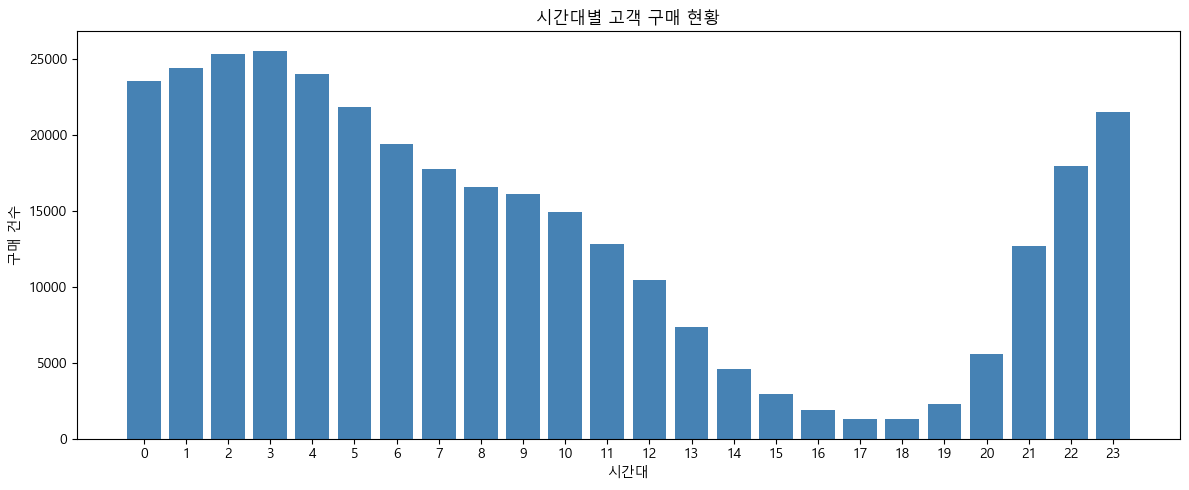

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시간대별 막대 그래프
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour'], hourly['count'], color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 고객 구매 현황')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [13]:
def time_segment(hour):
    if 6 <= hour < 12:
        return '오전 (6-12시)'
    elif 12 <= hour < 18:
        return '오후 (12-18시)'
    elif 18 <= hour < 24:
        return '저녁 (18-24시)'
    else:
        return '새벽 (0-6시)'

purchases['time_segment'] = purchases['hour'].apply(time_segment)
print(purchases['time_segment'].value_counts())

time_segment
새벽 (0-6시)      144723
오전 (6-12시)      97456
저녁 (18-24시)     61296
오후 (12-18시)     28497
Name: count, dtype: int64


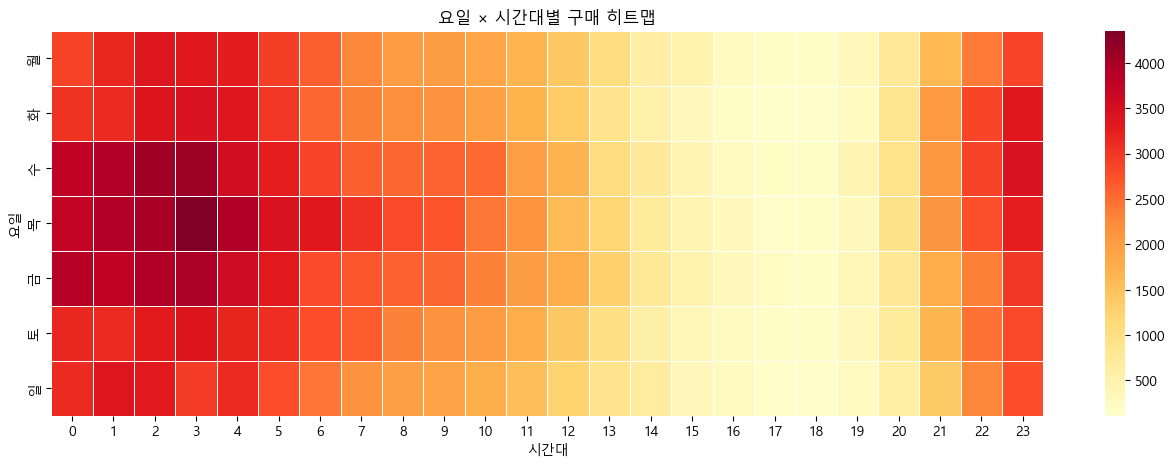

In [14]:
import seaborn as sns

heatmap_data = purchases.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['월', '화', '수', '목', '금', '토', '일']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('요일 × 시간대별 구매 히트맵')
plt.xlabel('시간대')
plt.ylabel('요일')
plt.show()

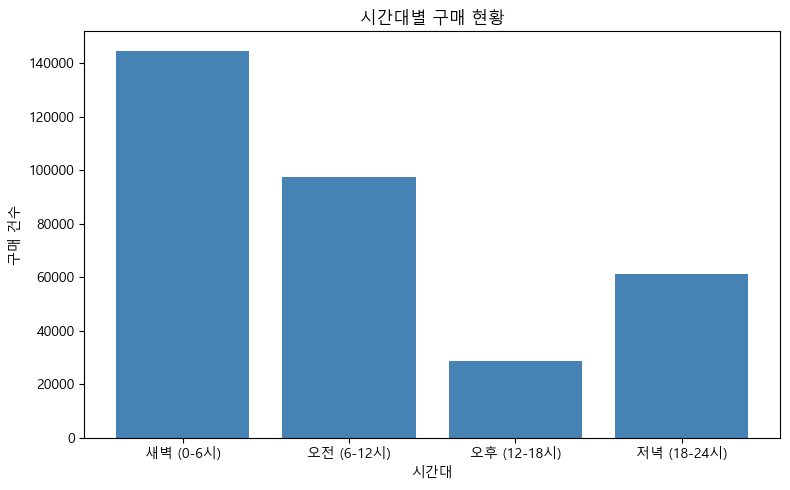

In [15]:

# 구매 이벤트 필터링 & 시간대 구간 추출
purchases = df[df['event_type'] == 'purchase'].copy()
purchases['hour'] = purchases['event_time'].dt.hour
purchases['time_segment'] = purchases['hour'].apply(time_segment)

# 순서 지정
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
segment_counts = purchases['time_segment'].value_counts().reindex(segment_order)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values, color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 구매 현황')
plt.tight_layout()
plt.show()

In [16]:
#구매 전환 소요 시간 계산

# 구매가 있는 세션만 필터링
sessions_with_purchase = df[df['event_type'] == 'purchase']['user_session'].unique()
df_filtered = df[df['user_session'].isin(sessions_with_purchase)]

# 세션별 첫 view 시간
first_view = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_view_time')
)

# 세션별 첫 purchase 시간
first_purchase = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_purchase_time')
)

# 합치기
conversion = pd.concat([first_view, first_purchase], axis=1).dropna()

# 전환까지 걸린 시간 (분 단위)
conversion['conversion_minutes'] = (
    conversion['first_purchase_time'] - conversion['first_view_time']
).dt.total_seconds() / 60

# view가 purchase보다 늦은 이상한 케이스 제거
conversion = conversion[conversion['conversion_minutes'] >= 0]

print(conversion['conversion_minutes'].describe())

count    282942.000000
mean          5.569988
std          54.905839
min           0.116667
25%           1.183333
50%           2.450000
75%           5.066667
max       18276.233333
Name: conversion_minutes, dtype: float64


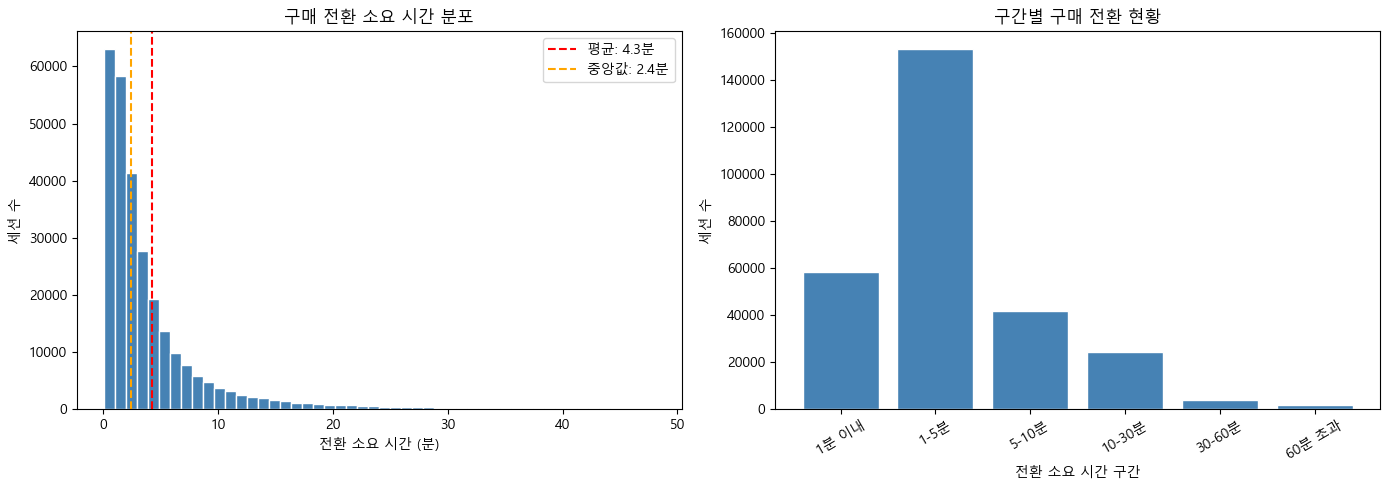

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이상치 제거 (상위 1%)
upper = conversion['conversion_minutes'].quantile(0.99)
data = conversion[conversion['conversion_minutes'] <= upper]['conversion_minutes']

# 1. 분포 히스토그램
axes[0].hist(data, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'평균: {data.mean():.1f}분')
axes[0].axvline(data.median(), color='orange', linestyle='--', label=f'중앙값: {data.median():.1f}분')
axes[0].set_xlabel('전환 소요 시간 (분)')
axes[0].set_ylabel('세션 수')
axes[0].set_title('구매 전환 소요 시간 분포')
axes[0].legend()

# 2. 구간별 막대 그래프
bins = [0, 1, 5, 10, 30, 60, float('inf')]
labels = ['1분 이내', '1-5분', '5-10분', '10-30분', '30-60분', '60분 초과']
conversion['time_bucket'] = pd.cut(conversion['conversion_minutes'], bins=bins, labels=labels)
bucket_counts = conversion['time_bucket'].value_counts().reindex(labels)

axes[1].bar(bucket_counts.index, bucket_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('전환 소요 시간 구간')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구간별 구매 전환 현황')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [18]:
# 1. 세션별 첫 view의 price 가져오기
first_view_price = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'price'])
    .rename('price')
)

# 2. 기존 price 컬럼 있으면 제거 후 합치기
conversion = conversion.drop(columns=['price'], errors='ignore')
conversion = conversion.join(first_view_price)

# 3. 가격대 구간
bins = [0, 50, 150, 300, 500, 1000, float('inf')]
labels = ['~$50', '$50-150', '$150-300', '$300-500', '$500-1000', '$1000+']

conversion['price_bucket'] = pd.cut(conversion['price'], bins=bins, labels=labels)

# 4. 구간별 평균/중앙값 전환 시간
price_conversion = conversion.groupby('price_bucket')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reset_index()

print(price_conversion)

  price_bucket        평균       중앙값      건수
0         ~$50  7.820432  3.916667     301
1      $50-150  5.919214  2.816667   56866
2     $150-300  6.022841  2.750000  100689
3     $300-500  6.205719  2.333333   31403
4    $500-1000  4.945212  2.116667   55987
5       $1000+  4.206883  1.916667   37663


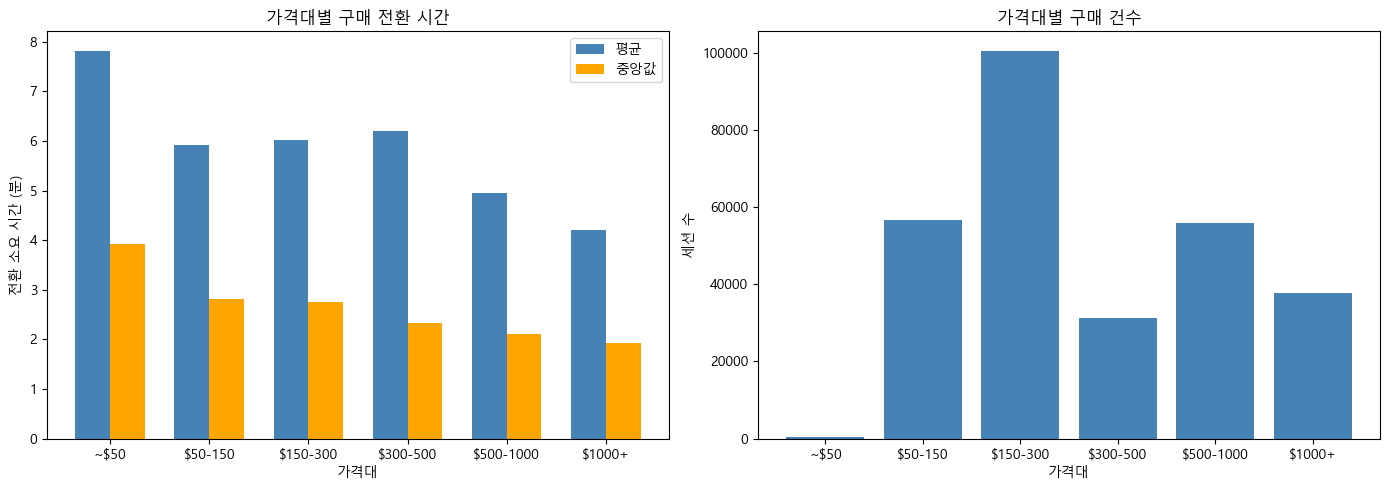

In [19]:
# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(price_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], price_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], price_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_conversion['price_bucket'])
axes[0].set_xlabel('가격대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('가격대별 구매 전환 시간')
axes[0].legend()

# 가격대별 건수
axes[1].bar(price_conversion['price_bucket'], price_conversion['건수'], color='steelblue')
axes[1].set_xlabel('가격대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('가격대별 구매 건수')

plt.tight_layout()
plt.show()

In [20]:
print(conversion['price'].describe())
print(conversion['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    282942.000000
mean        468.802352
std         408.286555
min           0.000000
25%         170.920000
50%         257.150000
75%         729.750000
max        2110.450000
Name: price, dtype: float64
0.25     170.92
0.50     257.15
0.75     729.75
0.90    1007.97
0.95    1412.79
0.99    1741.34
Name: price, dtype: float64


In [21]:
# 1. 첫 view 시간에서 시간대 추출
conversion['hour'] = conversion['first_purchase_time'].dt.hour
conversion['time_segment'] = conversion['hour'].apply(time_segment)

# 2. 시간대별 평균/중앙값 전환 시간
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
time_conversion = conversion.groupby('time_segment')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reindex(segment_order).reset_index()

print(time_conversion)

  time_segment        평균       중앙값      건수
0    새벽 (0-6시)  5.512702  2.383333  123400
1   오전 (6-12시)  6.271098  2.683333   83263
2  오후 (12-18시)  5.027673  2.283333   23487
3  저녁 (18-24시)  4.839383  2.333333   52792


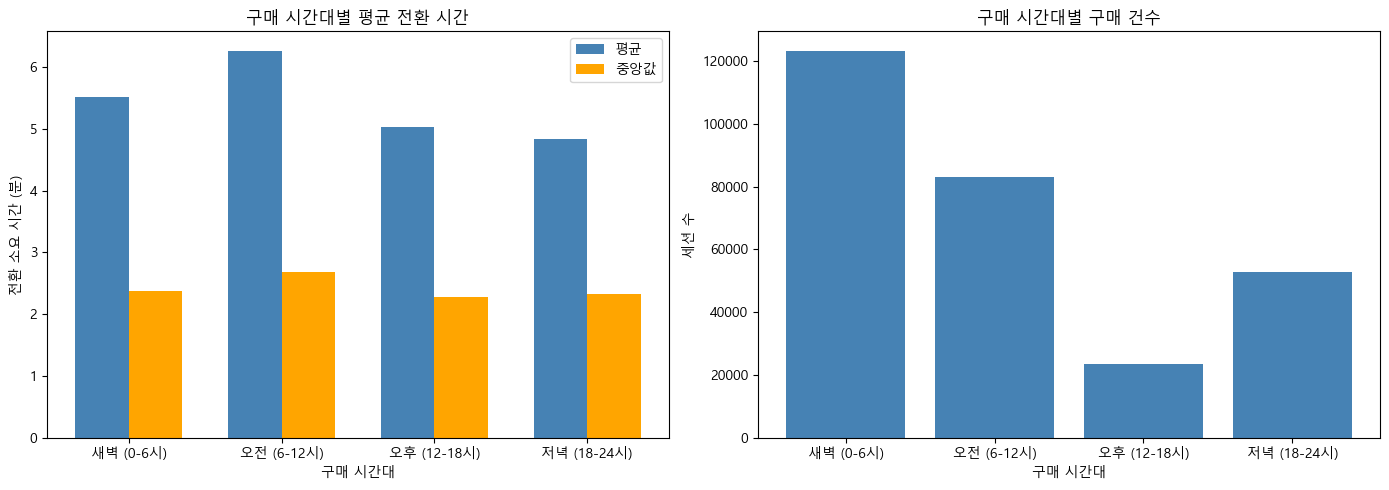

In [22]:
# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(time_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], time_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], time_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(time_conversion['time_segment'])
axes[0].set_xlabel('구매 시간대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('구매 시간대별 평균 전환 시간')
axes[0].legend()

# 시간대별 구매 건수
axes[1].bar(time_conversion['time_segment'], time_conversion['건수'], color='steelblue')
axes[1].set_xlabel('구매 시간대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구매 시간대별 구매 건수')

plt.tight_layout()
plt.show()

In [23]:
# 1. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 2. conversion 테이블에 brand 합치기
conversion = conversion.drop(columns=['brand'], errors='ignore')
conversion = conversion.join(first_purchase_brand)

# 3. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균').head(10))  # 전환 빠른 상위 10개
print(brand_conversion.sort_values('평균').tail(10))  # 전환 느린 상위 10개

브랜드 수: 21
        brand        평균       중앙값      건수
0       apple  4.314355  1.966667   96497
21  prestigio  5.117893  2.616667     231
22    samsung  5.147918  2.516667  119118
31        zte  5.880292  3.716667     137
19    oneplus  6.225909  2.225000     440
12       inoi  6.615011  3.300000     151
20       oppo  6.689024  3.200000    9143
16      meizu  6.914848  3.416667    1411
28    unknown  6.975352  3.150000     355
3          bq  7.258333  3.725000      72
      brand         평균       중앙값     건수
11   huawei   7.724653  3.333333  18380
17    nokia   7.882370  3.916667    450
26  tp-link   8.142308  2.700000    312
29     vivo   8.186005  2.716667   1697
23     sony   8.232118  3.583333    439
15       lg   8.269771  4.441667    102
30   xiaomi   8.839808  3.350000  33083
24    tecno   9.150000  3.133333     81
9     honor   9.465105  3.300000    491
4    doogee  10.823423  4.683333     74


In [24]:
# 1. 스마트폰 카테고리의 구매 세션만 필터링
smartphone_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'] == 'electronics.smartphone')
]['user_session'].unique()

df_smartphone = df_filtered[df_filtered['user_session'].isin(smartphone_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_smartphone[df_smartphone['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_smartphone = conversion[conversion.index.isin(smartphone_sessions)].copy()
conversion_smartphone = conversion_smartphone.drop(columns=['brand'], errors='ignore')
conversion_smartphone = conversion_smartphone.join(first_purchase_brand)

# 4. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion_smartphone.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균'))

브랜드 수: 21
        brand         평균       중앙값      건수
0       apple   4.314355  1.966667   96497
21  prestigio   5.117893  2.616667     231
22    samsung   5.147918  2.516667  119118
31        zte   5.880292  3.716667     137
19    oneplus   6.225909  2.225000     440
12       inoi   6.615011  3.300000     151
20       oppo   6.689024  3.200000    9143
16      meizu   6.914848  3.416667    1411
28    unknown   6.975352  3.150000     355
3          bq   7.258333  3.725000      72
8       haier   7.453382  4.450000      69
11     huawei   7.724653  3.333333   18380
17      nokia   7.882370  3.916667     450
26    tp-link   8.142308  2.700000     312
29       vivo   8.186005  2.716667    1697
23       sony   8.232118  3.583333     439
15         lg   8.269771  4.441667     102
30     xiaomi   8.839808  3.350000   33083
24      tecno   9.150000  3.133333      81
9       honor   9.465105  3.300000     491
4      doogee  10.823423  4.683333      74


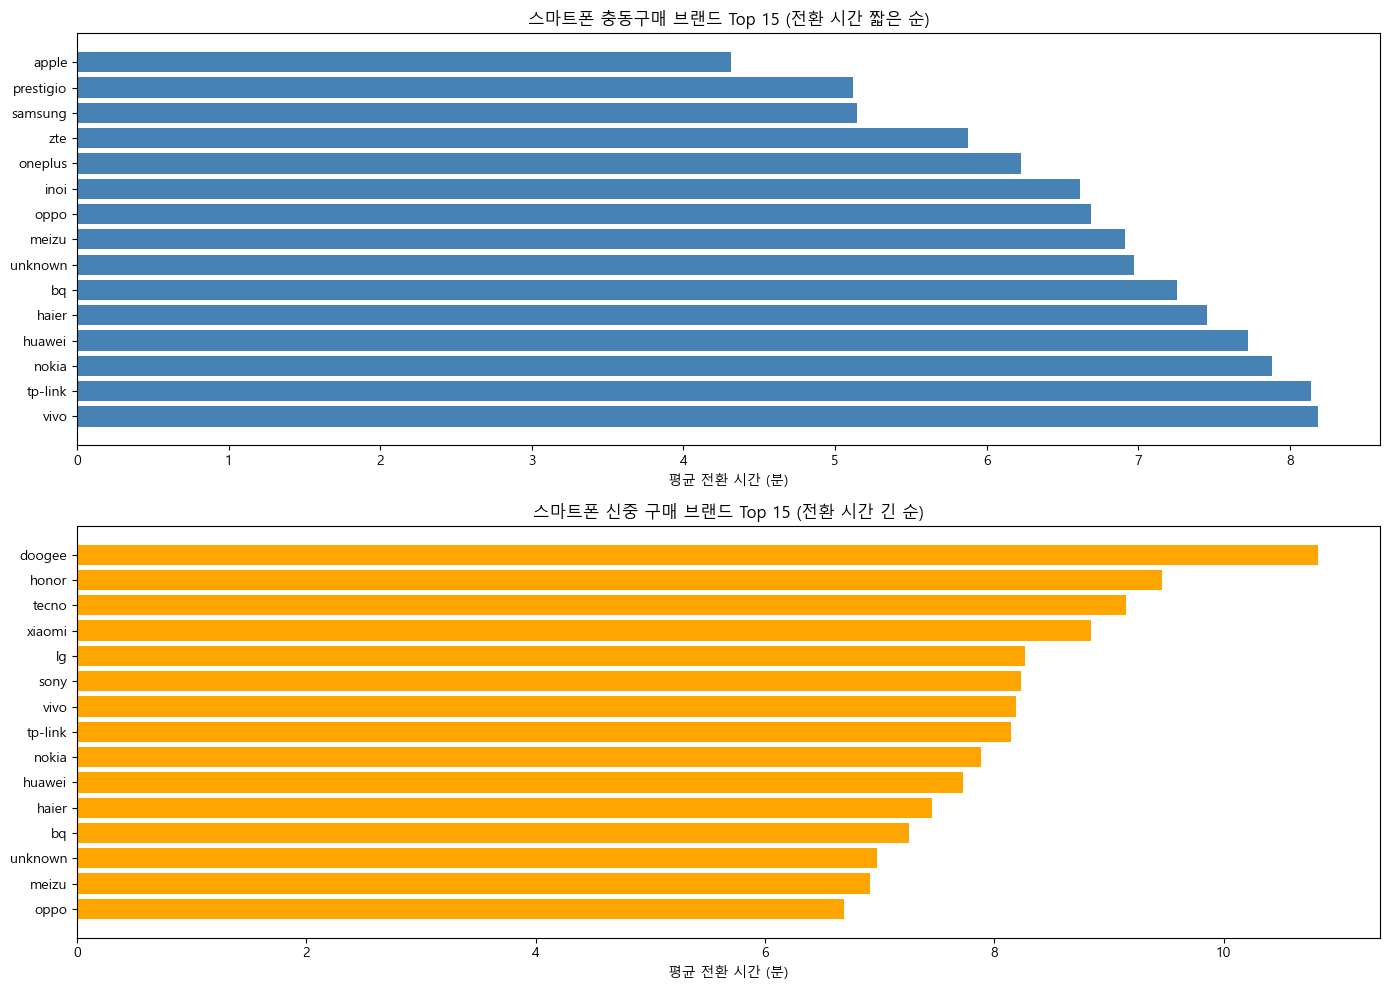

In [25]:
# 5. 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('스마트폰 충동구매 브랜드 Top 15 (전환 시간 짧은 순)')
axes[0].invert_yaxis()

axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('스마트폰 신중 구매 브랜드 Top 15 (전환 시간 긴 순)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt

# 1. 전자제품 세션 필터링
electronics_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'].str.contains('electronics', na=False))
]['user_session'].unique()

df_electronics = df_filtered[df_filtered['user_session'].isin(electronics_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_electronics[df_electronics['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_electronics = conversion[conversion.index.isin(electronics_sessions)].copy()
conversion_electronics = conversion_electronics.drop(columns=['brand'], errors='ignore')
conversion_electronics = conversion_electronics.join(first_purchase_brand)

# 4. 브랜드별 집계 (건수 10건 이상만)
brand_conversion = (
    conversion_electronics.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 10].sort_values('평균')

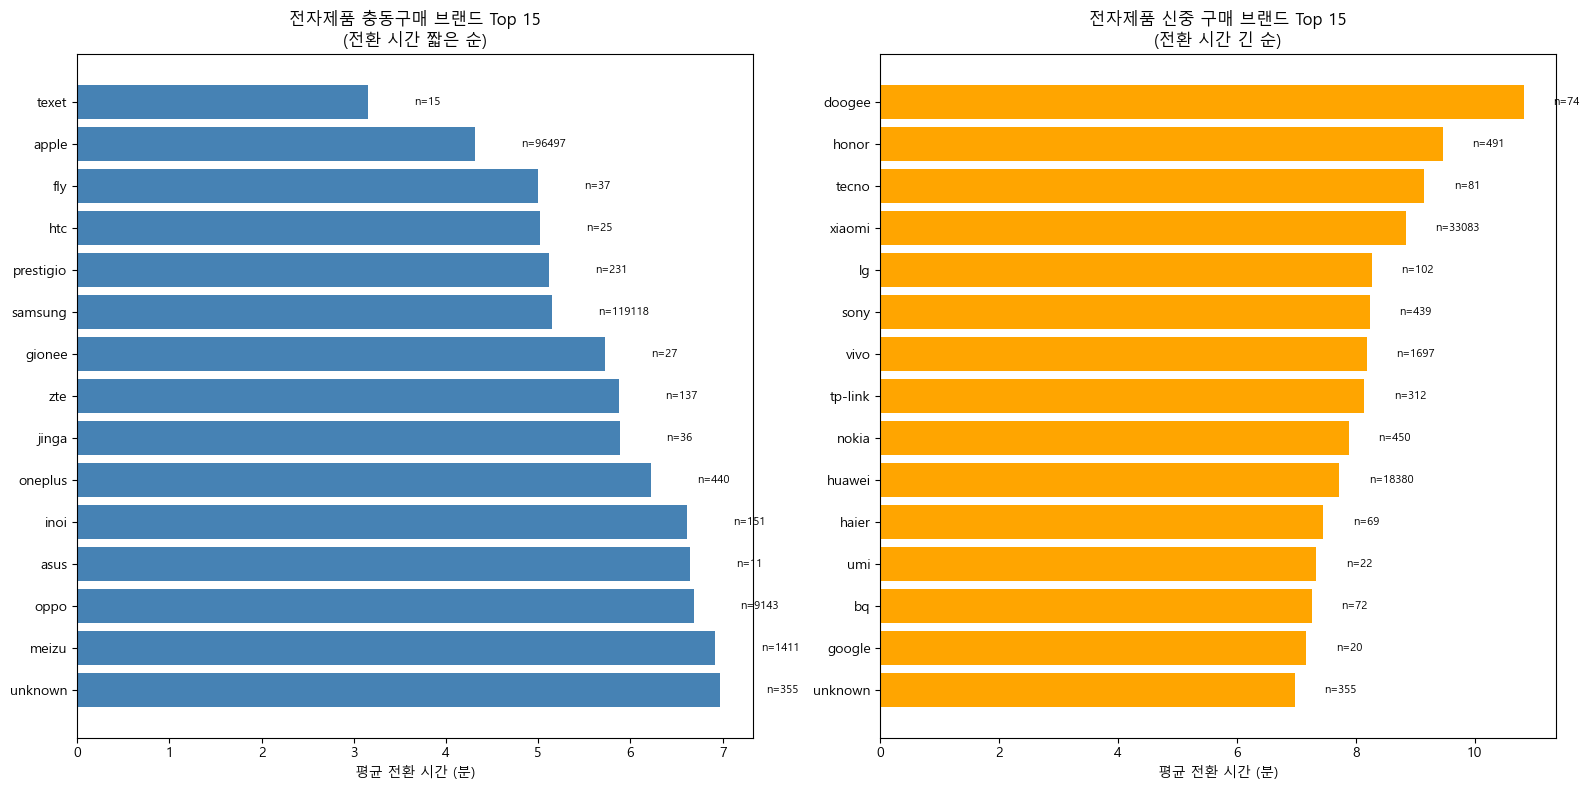

In [27]:

# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

# 충동구매 브랜드
bars1 = axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('전자제품 충동구매 브랜드 Top 15\n(전환 시간 짧은 순)')
axes[0].invert_yaxis()
# 건수 표시
for bar, count in zip(bars1, top_fast['건수']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

# 신중 구매 브랜드
bars2 = axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('전자제품 신중 구매 브랜드 Top 15\n(전환 시간 긴 순)')
axes[1].invert_yaxis()
# 건수 표시
for bar, count in zip(bars2, top_slow['건수']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
# 1. 세션별 view 횟수 집계
view_counts = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .size()
    .rename('view_count')
)

# 2. conversion 테이블에 view 횟수 합치기
conversion = conversion.drop(columns=['view_count'], errors='ignore')
conversion = conversion.join(view_counts)

print(conversion['view_count'].describe())

count    282942.000000
mean          4.108188
std           4.762999
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         174.000000
Name: view_count, dtype: float64


In [29]:
bins = [0, 1, 2, 3, 5, 10, float('inf')]
labels = ['1회', '2회', '3회', '4-5회', '6-10회', '11회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값     건수
0          1회   2.450088   1.716667  52714
1          2회   2.678103   1.650000  80105
2          3회   3.721764   2.250000  46798
3        4-5회   5.668839   3.216667  47663
4       6-10회   9.297530   5.416667  37550
5        11회+  24.227746  13.033333  18112


In [30]:
bins = [0, 3, 6, 10, 20, float('inf')]
labels = ['1-3회', '4-6회', '7-10회', '11-20회', '21회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값      건수
0        1-3회   2.883104   1.800000  179617
1        4-6회   6.123456   3.416667   60494
2       7-10회  10.068519   6.083333   24719
3      11-20회  19.135287  11.150000   14006
4        21회+  41.598660  24.291667    4106


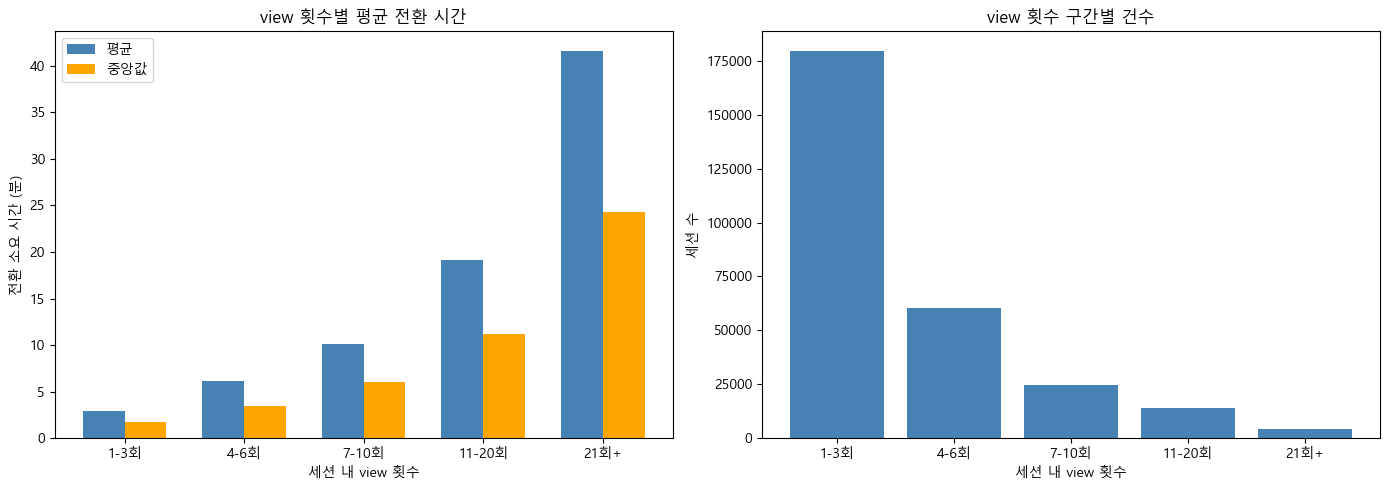

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(view_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], view_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], view_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(view_conversion['view_bucket'])
axes[0].set_xlabel('세션 내 view 횟수')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('view 횟수별 평균 전환 시간')
axes[0].legend()

axes[1].bar(view_conversion['view_bucket'], view_conversion['건수'], color='steelblue')
axes[1].set_xlabel('세션 내 view 횟수')
axes[1].set_ylabel('세션 수')
axes[1].set_title('view 횟수 구간별 건수')

plt.tight_layout()
plt.show()

#추가 분석

In [32]:
# 1. 새 bins로 speed_group 생성
bins = [0, 1, 3, 10, 30, float('inf')]
labels = ['즉시(~1분)', '빠름(1-3분)', '탐색(3-10분)', '신중(10-30분)', '장기고민(30분+)']

conversion['speed_group'] = pd.cut(
    conversion['conversion_minutes'],
    bins=bins,
    labels=labels
)

# 2. group_profile 생성
group_profile = conversion.groupby('speed_group', observed=True).agg(
    세션수=('conversion_minutes', 'count'),
    평균전환시간=('conversion_minutes', 'mean'),
    평균가격=('price', 'mean'),
    중앙값가격=('price', 'median'),
).reset_index()

group_profile['비율(%)'] = (group_profile['세션수'] / group_profile['세션수'].sum() * 100).round(1)
print(group_profile)

  speed_group     세션수     평균전환시간        평균가격   중앙값가격  비율(%)
0     즉시(~1분)   58250   0.614692  543.856861  360.11   20.6
1    빠름(1-3분)  104843   1.885605  485.777569  280.26   37.1
2   탐색(3-10분)   89858   5.302692  428.013486  250.82   31.8
3  신중(10-30분)   24128  15.935394  384.955228  241.17    8.5
4  장기고민(30분+)    5863  82.126335  389.766287  243.45    2.1


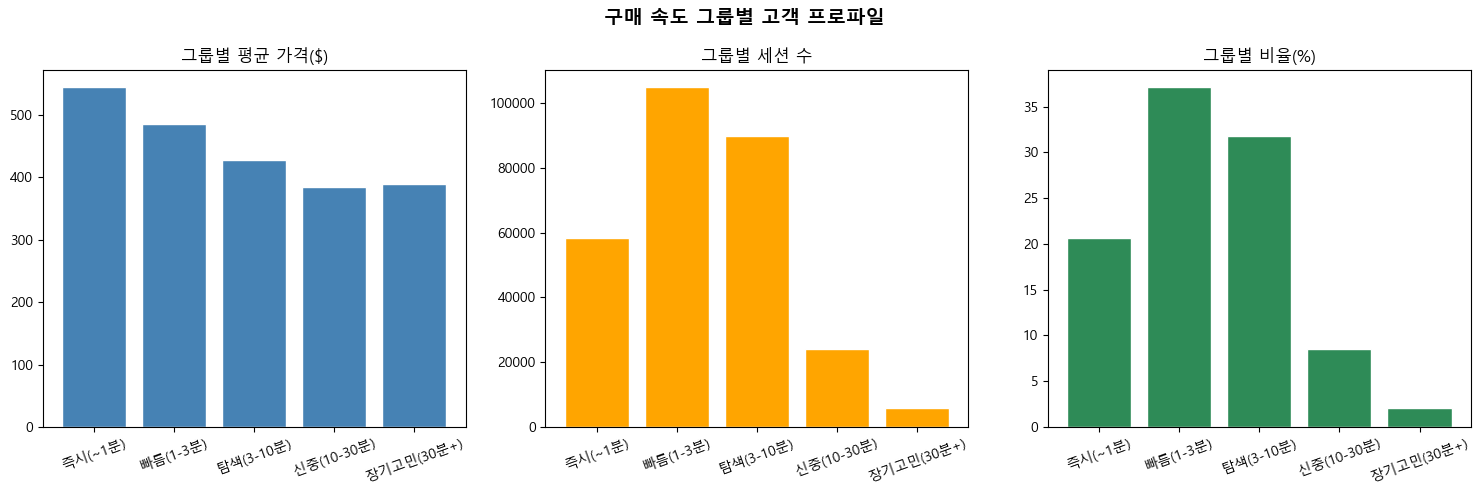

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['평균가격', '세션수', '비율(%)']
titles = ['그룹별 평균 가격($)', '그룹별 세션 수', '그룹별 비율(%)']
colors = ['steelblue', 'orange', 'seagreen']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(group_profile['speed_group'], group_profile[metric], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('구매 속도 그룹별 고객 프로파일', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# 세션별 이벤트 타입 존재 여부 확인
session_events = df_filtered.groupby('user_session')['event_type'].apply(set).reset_index()
session_events.columns = ['user_session', 'event_set']

session_events['has_view']     = session_events['event_set'].apply(lambda x: 'view' in x)
session_events['has_cart']     = session_events['event_set'].apply(lambda x: 'cart' in x)
session_events['has_purchase'] = session_events['event_set'].apply(lambda x: 'purchase' in x)

# conversion 테이블에 합치기
conversion = conversion.join(
    session_events.set_index('user_session')[['has_view', 'has_cart', 'has_purchase']],
    on='user_session'  # conversion의 index가 user_session인 경우
)

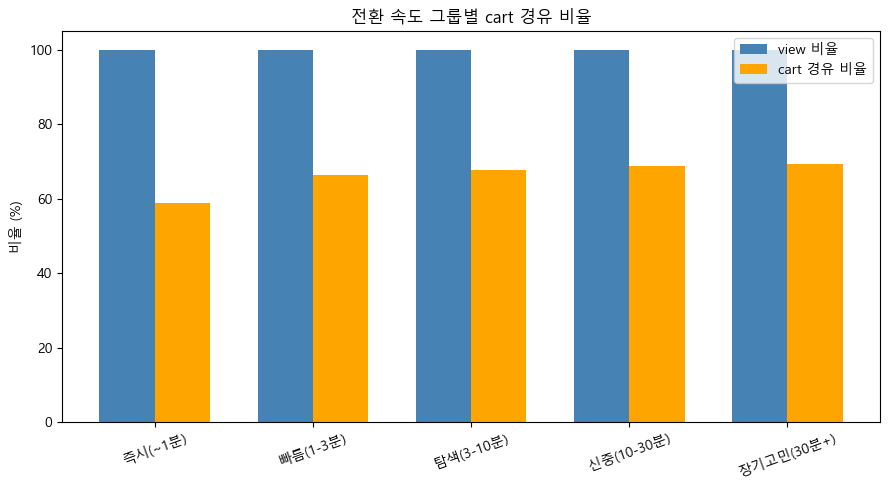

In [35]:
# 전환 속도 그룹별 cart 경유 비율
funnel_by_speed = conversion.groupby('speed_group').agg(
    view_비율=('has_view', 'mean'),
    cart_경유비율=('has_cart', 'mean'),
    세션수=('conversion_minutes', 'count')
).reset_index()

funnel_by_speed[['view_비율', 'cart_경유비율']] *= 100

# 시각화
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(funnel_by_speed))
width = 0.35

ax.bar([i - width/2 for i in x], funnel_by_speed['view_비율'],
       width=width, label='view 비율', color='steelblue')
ax.bar([i + width/2 for i in x], funnel_by_speed['cart_경유비율'],
       width=width, label='cart 경유 비율', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(funnel_by_speed['speed_group'])
ax.set_ylabel('비율 (%)')
ax.set_title('전환 속도 그룹별 cart 경유 비율')
ax.legend()
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [36]:
print(group_profile[['speed_group', '세션수']])

  speed_group     세션수
0     즉시(~1분)   58250
1    빠름(1-3분)  104843
2   탐색(3-10분)   89858
3  신중(10-30분)   24128
4  장기고민(30분+)    5863


In [37]:

# 세션별 이벤트 타입별 횟수 집계
session_event_counts = (
    df_filtered.groupby(['user_session', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 컬럼명 정리 (없는 이벤트 타입 대비)
for col in ['view', 'cart', 'purchase']:
    if col not in session_event_counts.columns:
        session_event_counts[col] = 0

session_event_counts = session_event_counts.rename(columns={
    'view': 'view_count',
    'cart': 'cart_count',
    'purchase': 'purchase_count'
})

# 기존 컬럼 제거 후 다시 합치기
conversion = conversion.drop(columns=['view_count', 'cart_count', 'purchase_count'], errors='ignore')

# conversion에 합치기
conversion = conversion.join(
    session_event_counts.set_index('user_session')[['view_count', 'cart_count', 'purchase_count']],
    on='user_session'
)

# 구매 경로 패턴 정의
def classify_path(row):
    if row['cart_count'] == 0:
        return 'view→purchase (cart 스킵)'
    else:
        return 'view→cart→purchase'

conversion['purchase_path'] = conversion.apply(classify_path, axis=1)

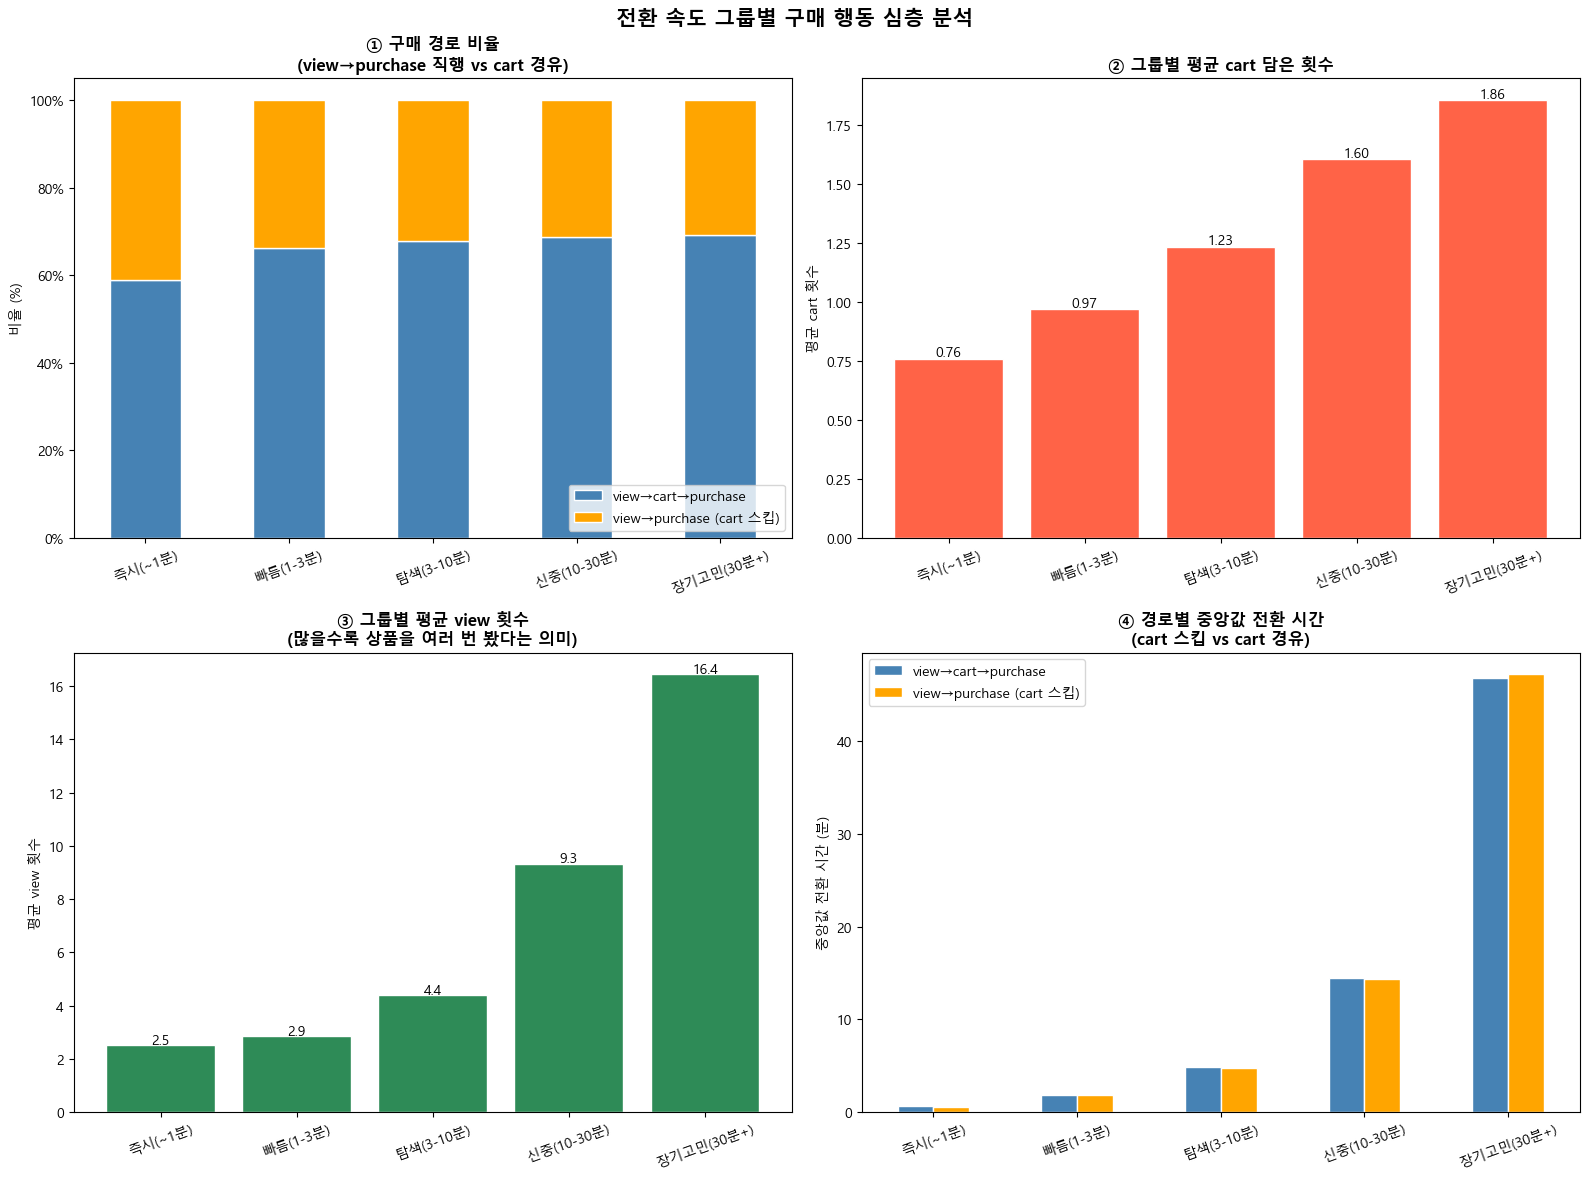

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

labels = ['즉시(~1분)', '빠름(1-3분)', '탐색(3-10분)', '신중(10-30분)', '장기고민(30분+)']

# ① 구매 경로 비율 (cart 스킵 vs cart 경유)
path_ratio = (
    conversion.groupby(['speed_group', 'purchase_path'], observed=True)
    .size()
    .unstack(fill_value=0)
)
path_ratio_pct = path_ratio.div(path_ratio.sum(axis=1), axis=0) * 100

path_ratio_pct.plot(kind='bar', stacked=True, ax=axes[0][0],
                    color=['steelblue', 'orange'], edgecolor='white')
axes[0][0].set_title('① 구매 경로 비율\n(view→purchase 직행 vs cart 경유)', fontweight='bold')
axes[0][0].set_xlabel('')
axes[0][0].set_ylabel('비율 (%)')
axes[0][0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0][0].tick_params(axis='x', rotation=20)
axes[0][0].legend(loc='lower right')

# ② 그룹별 평균 cart 담은 횟수
cart_avg = conversion.groupby('speed_group', observed=True)['cart_count'].mean().reindex(labels)

axes[0][1].bar(labels, cart_avg, color='tomato', edgecolor='white')
axes[0][1].set_title('② 그룹별 평균 cart 담은 횟수', fontweight='bold')
axes[0][1].set_xlabel('')
axes[0][1].set_ylabel('평균 cart 횟수')
axes[0][1].tick_params(axis='x', rotation=20)
for i, v in enumerate(cart_avg):
    axes[0][1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

# ③ 그룹별 평균 view 횟수
view_avg = conversion.groupby('speed_group', observed=True)['view_count'].mean().reindex(labels)

axes[1][0].bar(labels, view_avg, color='seagreen', edgecolor='white')
axes[1][0].set_title('③ 그룹별 평균 view 횟수\n(많을수록 상품을 여러 번 봤다는 의미)', fontweight='bold')
axes[1][0].set_xlabel('')
axes[1][0].set_ylabel('평균 view 횟수')
axes[1][0].tick_params(axis='x', rotation=20)
for i, v in enumerate(view_avg):
    axes[1][0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=10)

# ④ cart 스킵 그룹 vs cart 경유 그룹의 평균 전환 시간 비교
path_conv_time = conversion.groupby(['speed_group', 'purchase_path'], observed=True)['conversion_minutes'].median().unstack()

path_conv_time.plot(kind='bar', ax=axes[1][1],
                    color=['steelblue', 'orange'], edgecolor='white')
axes[1][1].set_title('④ 경로별 중앙값 전환 시간\n(cart 스킵 vs cart 경유)', fontweight='bold')
axes[1][1].set_xlabel('')
axes[1][1].set_ylabel('중앙값 전환 시간 (분)')
axes[1][1].tick_params(axis='x', rotation=20)
axes[1][1].legend(loc='upper left')

plt.suptitle('전환 속도 그룹별 구매 행동 심층 분석', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# user_session이 인덱스인지 확인
print(conversion.index.name)
print(conversion.columns.tolist())

user_session
['first_view_time', 'first_purchase_time', 'conversion_minutes', 'time_bucket', 'price', 'price_bucket', 'hour', 'time_segment', 'brand', 'view_bucket', 'speed_group', 'has_view', 'has_cart', 'has_purchase', 'view_count', 'cart_count', 'purchase_count', 'purchase_path']


In [40]:
# 1. 유저별 세션 수 분포 확인
sessions_per_user = session_info.groupby('user_id')['user_session'].nunique()
print("유저별 세션 수 분포:")
print(sessions_per_user.value_counts().head(10))
print(f"\n세션 2개 이상 유저: {(sessions_per_user > 1).sum():,}명")

# 2. session_rank 분포 확인
print("\nsession_rank 분포:")
print(session_info['session_rank'].value_counts().head(10))

# 3. 구매 세션의 session_rank 분포
print("\n구매 세션의 session_rank 분포:")
print(session_info[session_info['has_purchase']]['session_rank'].value_counts().head(10))

# 4. df_filtered에 어떤 이벤트가 있는지 확인
print("\ndf_filtered event_type 분포:")
print(df_filtered['event_type'].value_counts())

NameError: name 'session_info' is not defined

In [ ]:
# 원본 데이터 이름 확인
# df 또는 df_raw 등 필터링 전 데이터 변수명 확인
print(df.shape)  # df가 원본이면 이걸로 확인

(11471296, 17)


In [ ]:
# =============================================
# 1. 원본 df로 세션 정보 집계
# =============================================
session_info = df.groupby(['user_id', 'user_session']).agg(
    session_start=('event_time', 'min'),
    has_purchase=('event_type', lambda x: (x == 'purchase').any())
).reset_index()

session_info = session_info.sort_values(['user_id', 'session_start'])
session_info['session_rank'] = session_info.groupby('user_id').cumcount() + 1

# =============================================
# 2. 유저별 첫 번째 구매 세션만 추출
# =============================================
first_purchase_session = (
    session_info[session_info['has_purchase']]
    .groupby('user_id')
    .first()
    .reset_index()
)

print(f"전체 유저 수: {first_purchase_session['user_id'].nunique():,}")
print(f"첫 방문 구매: {(first_purchase_session['session_rank'] == 1).sum():,}")
print(f"재방문 구매:  {(first_purchase_session['session_rank'] > 1).sum():,}")

first_purchase_session['visitor_type'] = first_purchase_session['session_rank'].apply(
    lambda x: '첫 방문 구매' if x == 1 else '재방문 구매'
)

# =============================================
# 3. conversion에서 해당 세션만 필터 + visitor_type 합치기
# =============================================
conversion_v2 = conversion[
    conversion.index.isin(first_purchase_session['user_session'])
].copy()

conversion_v2 = conversion_v2.drop(columns=['visitor_type'], errors='ignore')

conversion_v2 = conversion_v2.join(
    first_purchase_session.set_index('user_session')['visitor_type']
)

print(f"\nconversion_v2 세션 수: {len(conversion_v2):,}")
print(f"\nvisitor_type 분포:\n{conversion_v2['visitor_type'].value_counts()}")

전체 유저 수: 160,243
첫 방문 구매: 89,065
재방문 구매:  71,178

conversion_v2 세션 수: 159,677

visitor_type 분포:
visitor_type
첫 방문 구매    88777
재방문 구매     70900
Name: count, dtype: int64



  visitor_type    세션수        평균       중앙값       Q25       Q75
0       재방문 구매  70900  8.670379  4.000000  2.066667  8.200000
1      첫 방문 구매  88777  6.292111  3.133333  1.683333  5.916667


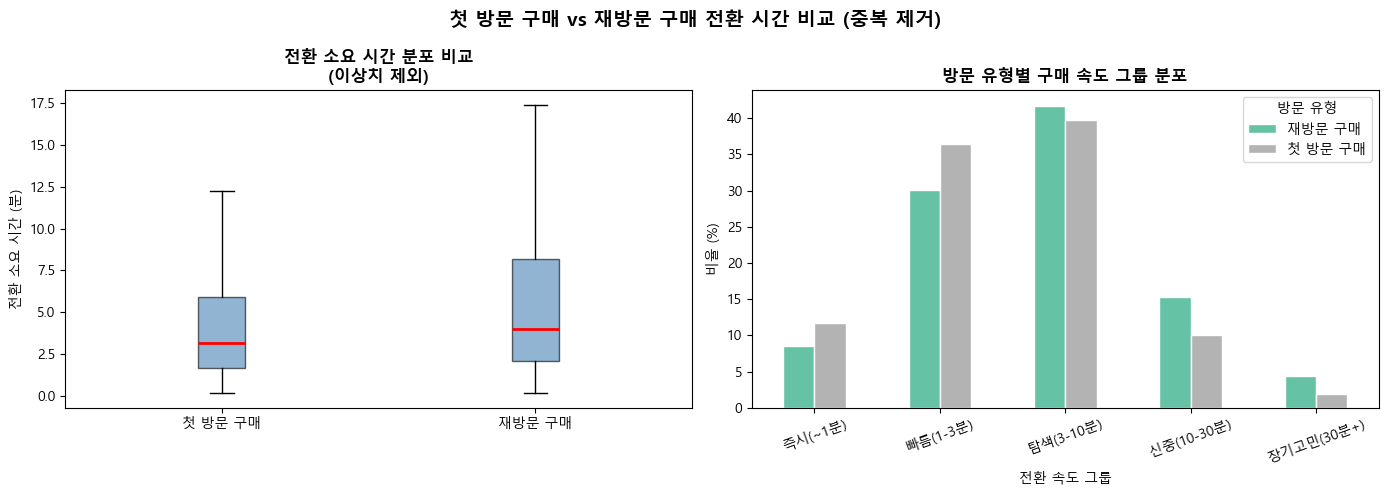

In [ ]:
# =============================================
# 4. 통계 요약
# =============================================
visitor_stats = conversion_v2.groupby('visitor_type')['conversion_minutes'].agg(
    세션수='count',
    평균='mean',
    중앙값='median',
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75)
).reset_index()
print(f"\n{visitor_stats}")

# =============================================
# 5. 시각화
# =============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_first  = conversion_v2[conversion_v2['visitor_type'] == '첫 방문 구매']['conversion_minutes'].dropna()
data_return = conversion_v2[conversion_v2['visitor_type'] == '재방문 구매']['conversion_minutes'].dropna()

# 박스플롯
axes[0].boxplot(
    [data_first, data_return],
    labels=['첫 방문 구매', '재방문 구매'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    showfliers=False
)
axes[0].set_title('전환 소요 시간 분포 비교\n(이상치 제외)', fontweight='bold')
axes[0].set_ylabel('전환 소요 시간 (분)')

# 속도 그룹 분포
speed_visitor = (
    conversion_v2.groupby(['visitor_type', 'speed_group'], observed=True)
    .size()
    .unstack(fill_value=0)
)
speed_visitor_pct = speed_visitor.div(speed_visitor.sum(axis=1), axis=0) * 100
speed_visitor_pct.T.plot(kind='bar', ax=axes[1], edgecolor='white', colormap='Set2')
axes[1].set_title('방문 유형별 구매 속도 그룹 분포', fontweight='bold')
axes[1].set_xlabel('전환 속도 그룹')
axes[1].set_ylabel('비율 (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='방문 유형')

plt.suptitle('첫 방문 구매 vs 재방문 구매 전환 시간 비교 (중복 제거)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()